In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
/Users/sayoojchandran/Desktop/Assignment/LGBM & XGBM

Files and folders here:
['.DS_Store', 'LGBM & XGBM.ipynb', 'models', 'README.md', '.venv', 'data', '.idea']


In [4]:
print("\nFiles inside data folder:")
print(os.listdir("data"))


Files inside data folder:
['diabetes.csv']


In [5]:
import pandas as pd

# Load the diabetes dataset
df = pd.read_csv("data/diabetes.csv")

# Display the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column names and data types
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Diabetes

In [7]:
# Statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


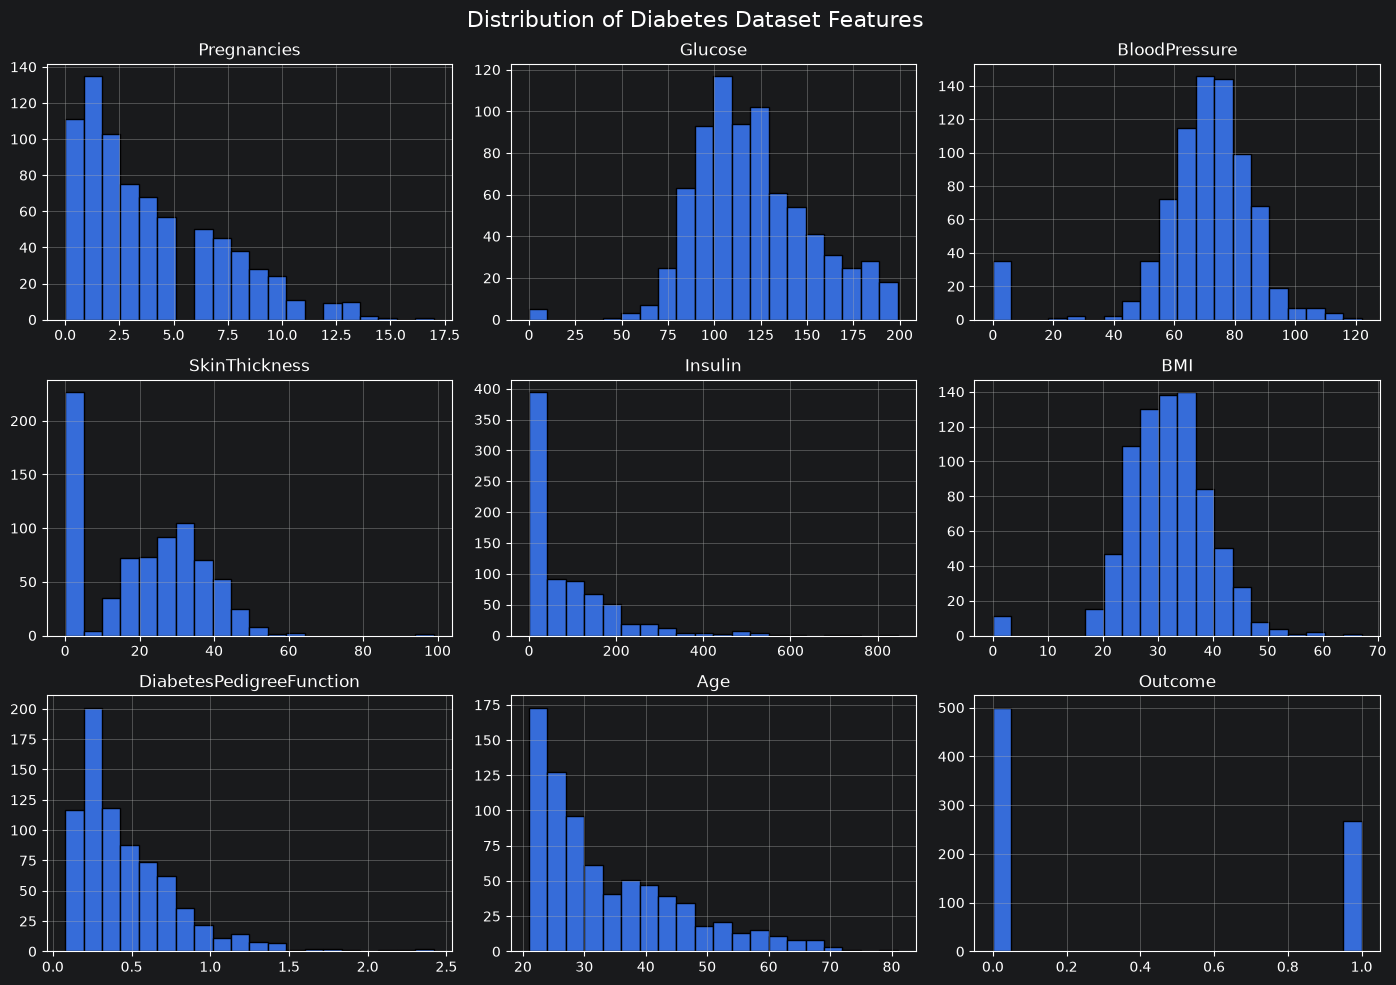

In [8]:
import matplotlib.pyplot as plt

# Plot histograms for all numerical features
df.hist(figsize=(14, 10), bins=20, edgecolor="black")

plt.suptitle("Distribution of Diabetes Dataset Features", fontsize=16)
plt.tight_layout()
plt.show()

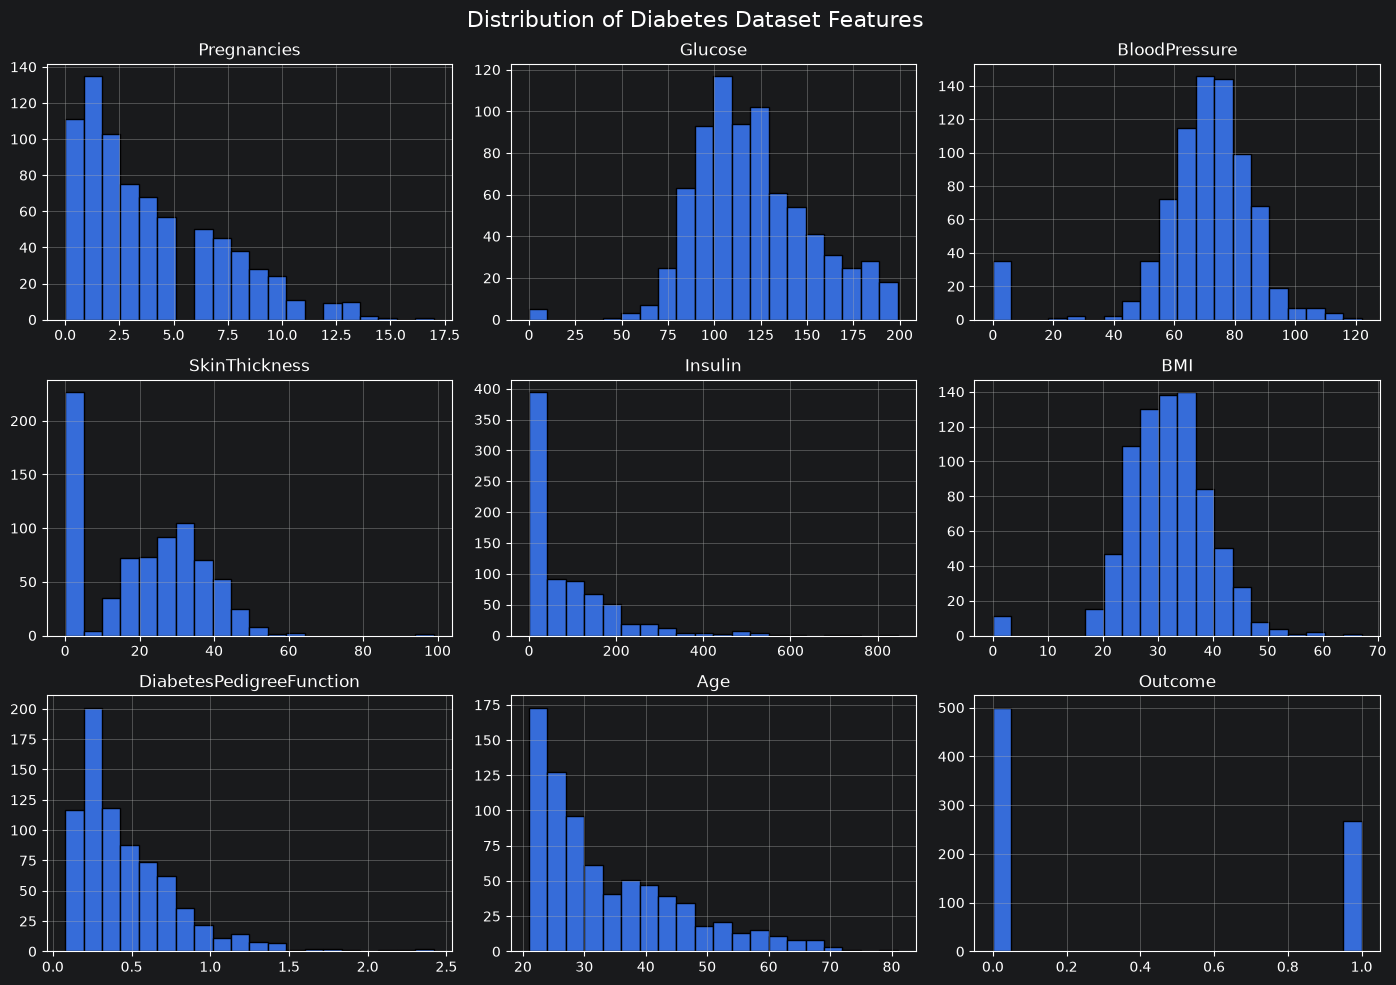

In [9]:
import matplotlib.pyplot as plt

# Plot histograms for all numerical features
df.hist(figsize=(14, 10), bins=20, edgecolor="black")

plt.suptitle("Distribution of Diabetes Dataset Features", fontsize=16)
plt.tight_layout()
plt.show()

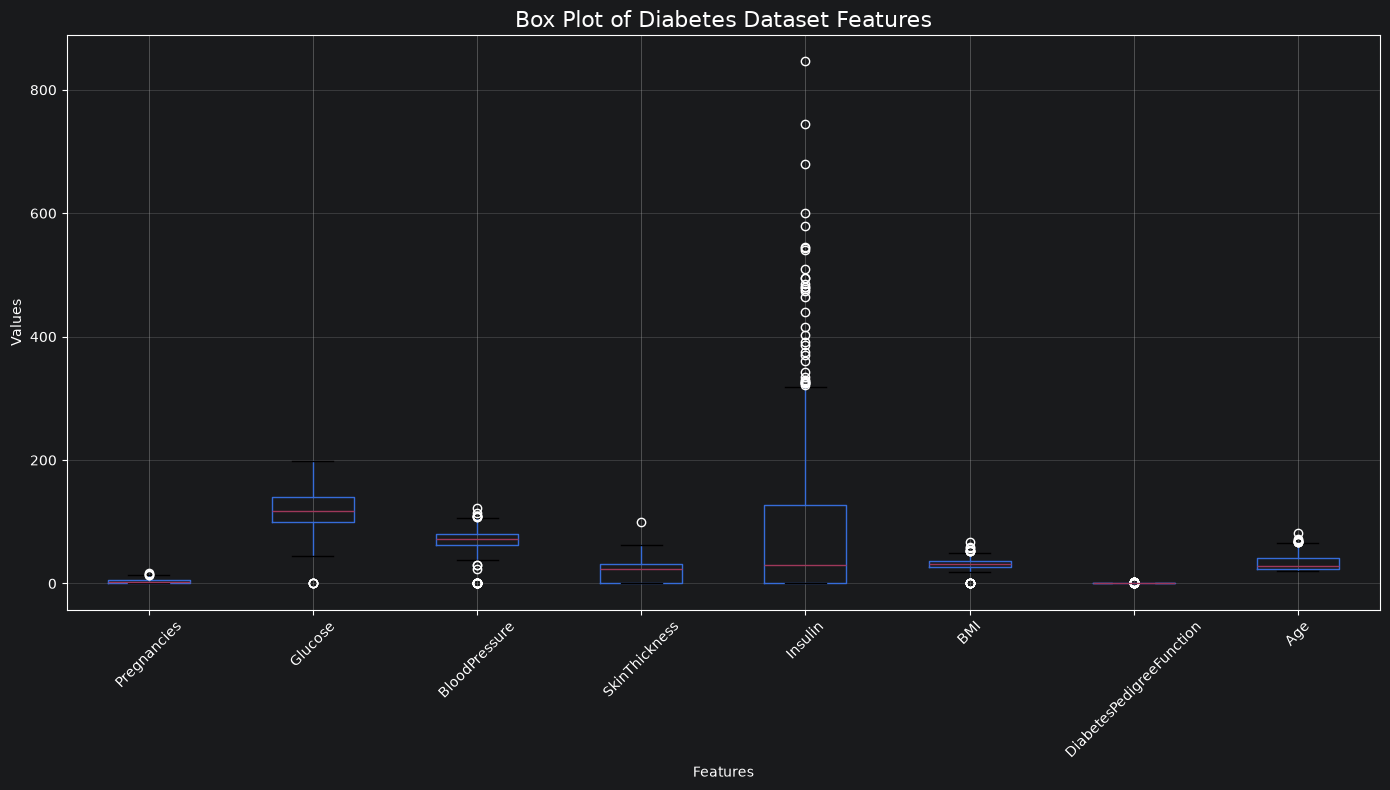

In [10]:
import matplotlib.pyplot as plt

# Select numerical features excluding the target variable
features = df.drop(columns=["Outcome"]).columns

# Create box plots
plt.figure(figsize=(14, 8))

df[features].boxplot()

plt.title("Box Plot of Diabetes Dataset Features", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

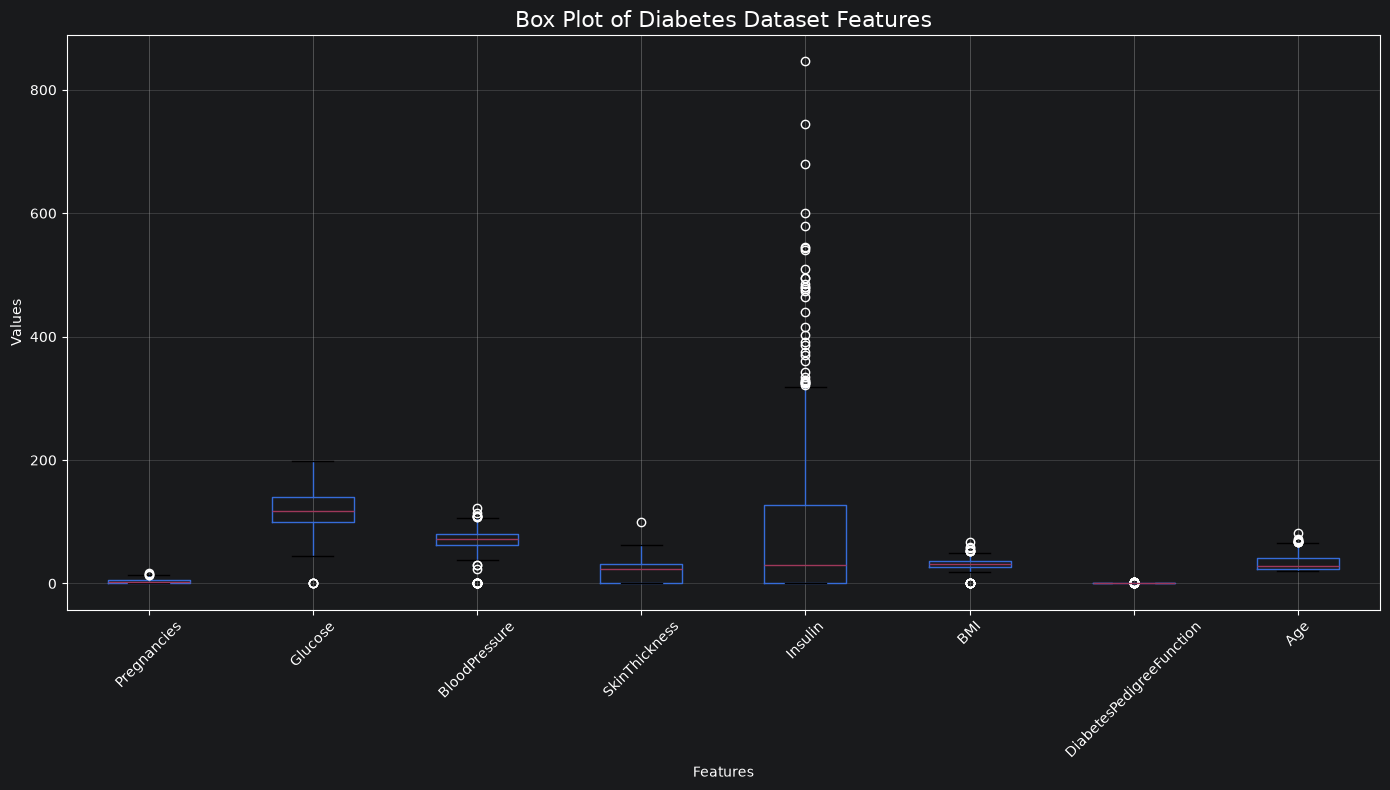

In [11]:
import matplotlib.pyplot as plt

# Select numerical features excluding the target variable
features = df.drop(columns=["Outcome"]).columns

# Create box plots
plt.figure(figsize=(14, 8))

df[features].boxplot()

plt.title("Box Plot of Diabetes Dataset Features", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Outcome Counts:
Outcome
0    500
1    268
Name: count, dtype: int64


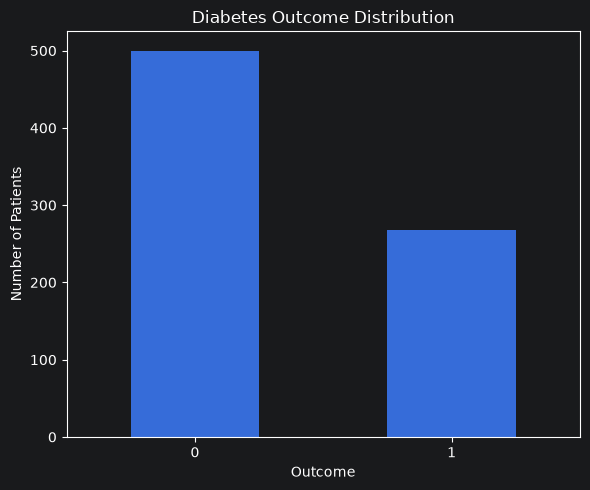

In [12]:
import matplotlib.pyplot as plt

# Count the target classes
outcome_counts = df["Outcome"].value_counts()

print("Outcome Counts:")
print(outcome_counts)

# Plot outcome distribution
plt.figure(figsize=(6, 5))
outcome_counts.plot(kind="bar")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

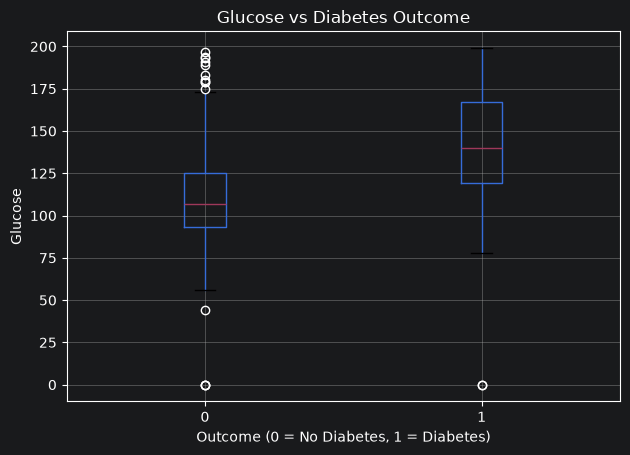

<Figure size 700x500 with 0 Axes>

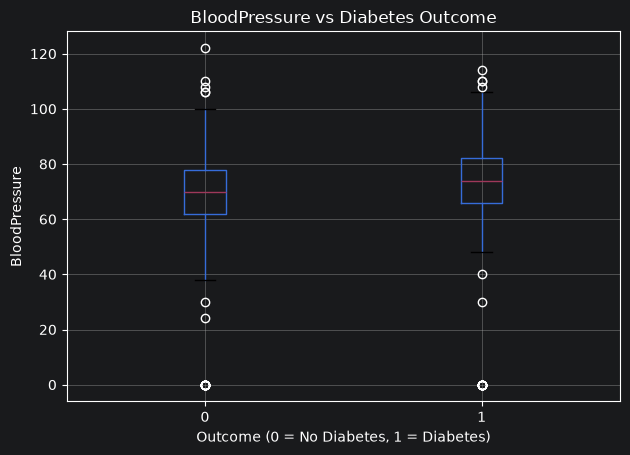

<Figure size 700x500 with 0 Axes>

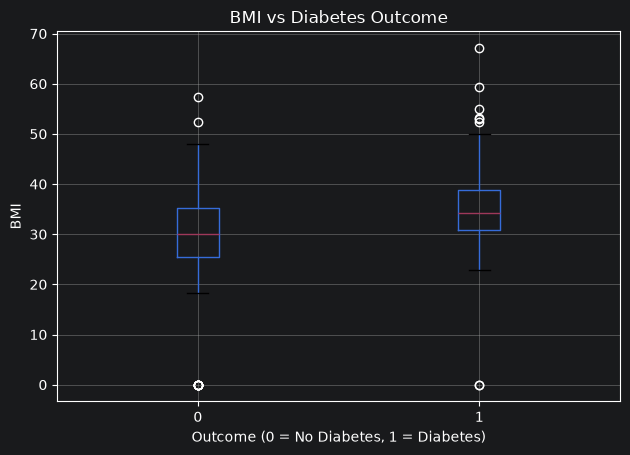

<Figure size 700x500 with 0 Axes>

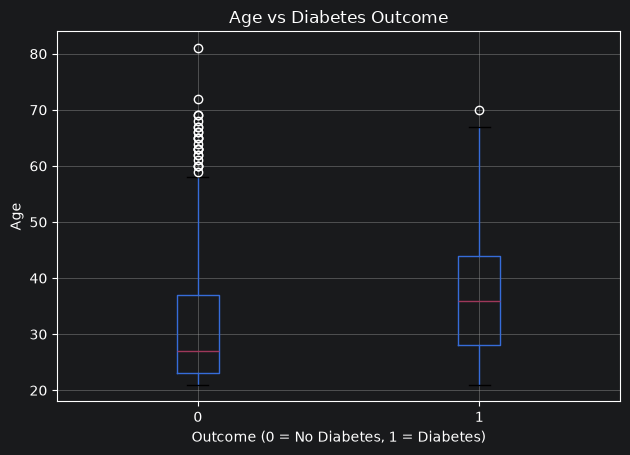

In [13]:
import matplotlib.pyplot as plt

# Features to compare with Outcome
selected_features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age"
]

# Create box plots grouped by Outcome
for feature in selected_features:
    plt.figure(figsize=(7, 5))

    df.boxplot(
        column=feature,
        by="Outcome"
    )

    plt.title(f"{feature} vs Diabetes Outcome")
    plt.suptitle("")
    plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np

# Create a copy of the dataset
data = df.copy()

# Columns where zero represents a missing/invalid measurement
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zero values with NaN
data[zero_columns] = data[zero_columns].replace(0, np.nan)

# Check the newly created missing values
print("Missing values after replacing zeros:")
print(data.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (614, 8)
Testing set shape: (154, 8)

Training target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [16]:
from sklearn.impute import SimpleImputer

# Create median imputer
imputer = SimpleImputer(strategy="median")

# Fit on training data and transform both datasets
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrames
X_train = pd.DataFrame(
    X_train_imputed,
    columns=X.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test_imputed,
    columns=X.columns,
    index=X_test.index
)

print("Missing values in training data:")
print(X_train.isnull().sum())

print("\nMissing values in testing data:")
print(X_test.isnull().sum())

Missing values in training data:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in testing data:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [17]:
import lightgbm
import xgboost

print("LightGBM version:", lightgbm.__version__)
print("XGBoost version:", xgboost.__version__)

LightGBM version: 4.7.0
XGBoost version: 3.4.1


In [18]:
from lightgbm import LGBMClassifier

# Create LightGBM classifier
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbosity=-1
)

# Train the model
lgbm_model.fit(X_train, y_train)

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_test)

# Calculate evaluation metrics
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_precision = precision_score(y_test, y_pred_lgbm)
lgbm_recall = recall_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)

print("LightGBM Performance")
print("-" * 30)
print(f"Accuracy  : {lgbm_accuracy:.4f}")
print(f"Precision : {lgbm_precision:.4f}")
print(f"Recall    : {lgbm_recall:.4f}")
print(f"F1-Score  : {lgbm_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

LightGBM Performance
------------------------------
Accuracy  : 0.7597
Precision : 0.6809
Recall    : 0.5926
F1-Score  : 0.6337

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



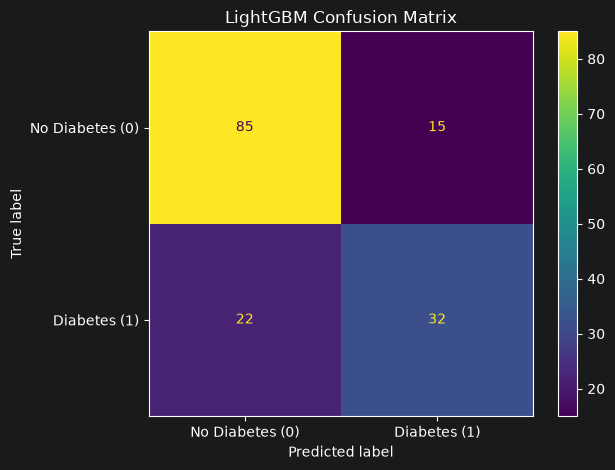

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot confusion matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["No Diabetes (0)", "Diabetes (1)"]
)

disp.plot()
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
from xgboost import XGBClassifier

# Create XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [22]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-" * 30)
print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-Score  : {xgb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance
------------------------------
Accuracy  : 0.7792
Precision : 0.7083
Recall    : 0.6296
F1-Score  : 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       100
           1       0.71      0.63      0.67        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.78      0.78      0.78       154



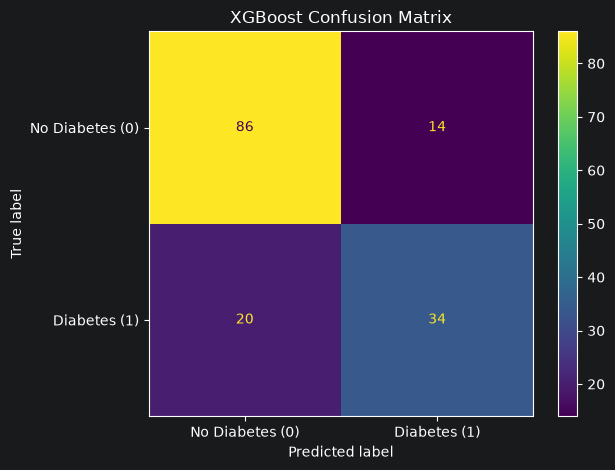

In [23]:
# Plot XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Diabetes (0)", "Diabetes (1)"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [lgbm_accuracy, xgb_accuracy],
    "Precision": [lgbm_precision, xgb_precision],
    "Recall": [lgbm_recall, xgb_recall],
    "F1-Score": [lgbm_f1, xgb_f1]
})

print(comparison)

      Model  Accuracy  Precision    Recall  F1-Score
0  LightGBM  0.759740   0.680851  0.592593  0.633663
1   XGBoost  0.779221   0.708333  0.629630  0.666667


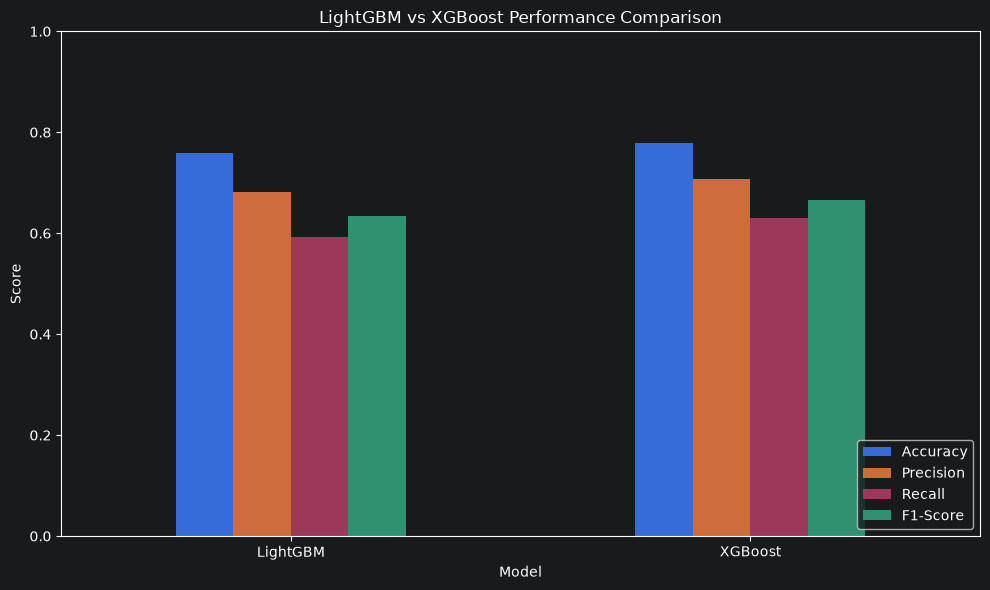

In [25]:
# Plot model performance comparison
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("LightGBM vs XGBoost Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# LightGBM parameter grid
lgbm_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 5],
    "num_leaves": [15, 31]
}

# Base LightGBM model
lgbm_base = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# Grid search
lgbm_grid = GridSearchCV(
    estimator=lgbm_base,
    param_grid=lgbm_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# Fit grid search on training data only
lgbm_grid.fit(X_train, y_train)

print("Best LightGBM Parameters:")
print(lgbm_grid.best_params_)

print("\nBest LightGBM Cross-Validation F1-Score:")
print(f"{lgbm_grid.best_score_:.4f}")

Best LightGBM Parameters:
{'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}

Best LightGBM Cross-Validation F1-Score:
0.6426


In [27]:
# XGBoost parameter grid
xgb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

# Base XGBoost model
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Grid search
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# Fit grid search on training data only
xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest XGBoost Cross-Validation F1-Score:")
print(f"{xgb_grid.best_score_:.4f}")

Best XGBoost Parameters:
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Best XGBoost Cross-Validation F1-Score:
0.6592


In [28]:
# Get the best tuned models
best_lgbm = lgbm_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# Predictions on the test set
y_pred_lgbm_tuned = best_lgbm.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)

# Calculate metrics
tuned_results = pd.DataFrame({
    "Model": ["Tuned LightGBM", "Tuned XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgbm_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgbm_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgbm_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lgbm_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ]
})

print("Optimized Model Performance")
print("-" * 60)
print(tuned_results.round(4))

Optimized Model Performance
------------------------------------------------------------
            Model  Accuracy  Precision  Recall  F1-Score
0  Tuned LightGBM    0.7727     0.6939  0.6296    0.6602
1   Tuned XGBoost    0.7403     0.6400  0.5926    0.6154


In [29]:
print("Tuned LightGBM Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_lgbm_tuned))

print("\nTuned XGBoost Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb_tuned))

Tuned LightGBM Classification Report
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       100
           1       0.69      0.63      0.66        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154


Tuned XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



In [30]:
# Final tuned model comparison
final_comparison = pd.DataFrame({
    "Model": ["Tuned LightGBM", "Tuned XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgbm_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgbm_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgbm_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lgbm_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ]
})

print("Final Tuned Model Comparison")
print("=" * 60)
print(final_comparison.round(4))

Final Tuned Model Comparison
            Model  Accuracy  Precision  Recall  F1-Score
0  Tuned LightGBM    0.7727     0.6939  0.6296    0.6602
1   Tuned XGBoost    0.7403     0.6400  0.5926    0.6154


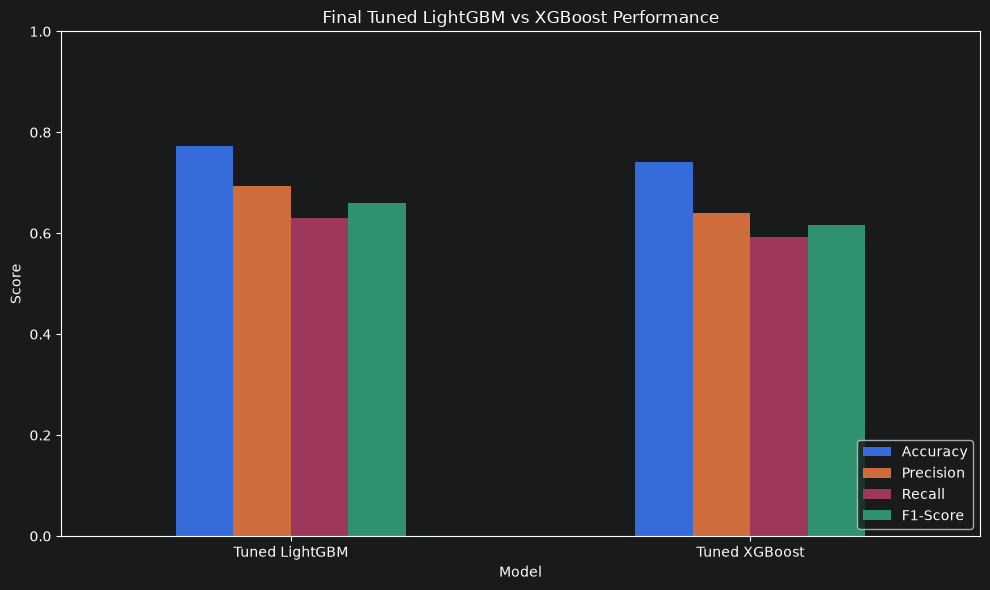

In [31]:
# Final performance visualization
final_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Tuned LightGBM vs XGBoost Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [32]:
# LightGBM feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_lgbm.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("Tuned LightGBM Feature Importance")
print("=" * 50)
print(feature_importance)

Tuned LightGBM Feature Importance
                    Feature  Importance
1                   Glucose         512
6  DiabetesPedigreeFunction         468
5                       BMI         438
7                       Age         328
0               Pregnancies         231
2             BloodPressure         199
4                   Insulin         195
3             SkinThickness         159


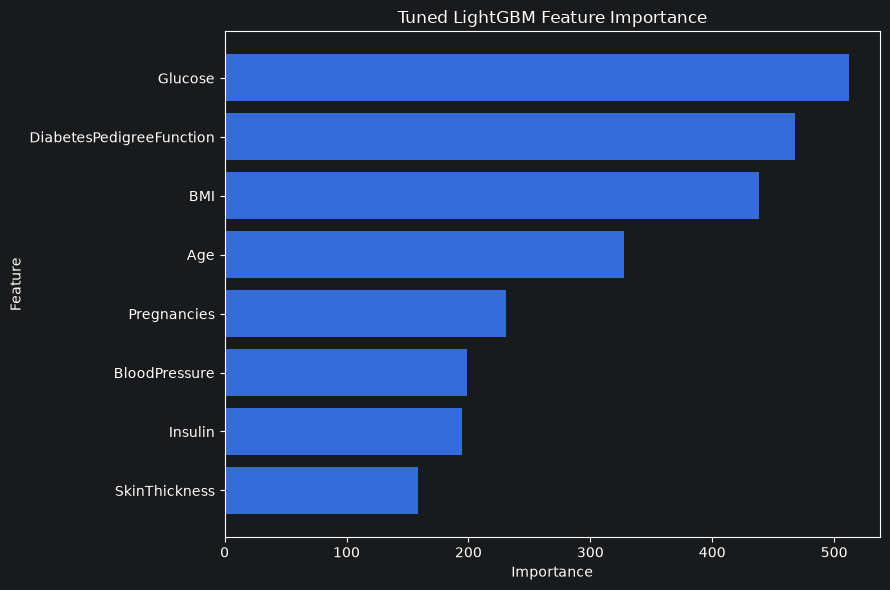

In [33]:
# Plot feature importance
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Tuned LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [34]:
# Final model comparison table
final_results = pd.DataFrame({
    "Model": ["Tuned LightGBM", "Tuned XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgbm_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgbm_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgbm_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lgbm_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ]
})

print("FINAL MODEL COMPARISON")
print("=" * 70)
print(final_results.round(4))

print("\nCross-Validation F1-Scores")
print("-" * 40)
print(f"Tuned LightGBM : {lgbm_grid.best_score_:.4f}")
print(f"Tuned XGBoost  : {xgb_grid.best_score_:.4f}")

FINAL MODEL COMPARISON
            Model  Accuracy  Precision  Recall  F1-Score
0  Tuned LightGBM    0.7727     0.6939  0.6296    0.6602
1   Tuned XGBoost    0.7403     0.6400  0.5926    0.6154

Cross-Validation F1-Scores
----------------------------------------
Tuned LightGBM : 0.6426
Tuned XGBoost  : 0.6592


In [35]:
# Save final comparison results
final_results.to_csv(
    "models/final_model_comparison.csv",
    index=False
)

# Save LightGBM feature importance
feature_importance.to_csv(
    "models/lightgbm_feature_importance.csv",
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


# LGBM and XGBM Comparative Analysis

## Objective

The objective of this analysis was to compare the performance of LightGBM and XGBoost classification algorithms on the diabetes dataset and identify the better-performing model.

## Exploratory Data Analysis

The dataset contains 768 observations and 9 columns, including 8 predictor variables and the target variable `Outcome`. The target variable contains 500 observations of class 0 and 268 observations of class 1.

Histograms and box plots were used to examine feature distributions and identify potential outliers. Several features, particularly Insulin, SkinThickness, BMI, and BloodPressure, contained extreme values. The analysis also identified zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI as invalid measurements.

## Data Preprocessing

The invalid zero values in the affected medical measurements were replaced with missing values and subsequently handled using median imputation. The data was divided into training and testing sets using an 80:20 split with stratification to preserve the target-class distribution.

The resulting training set contained 614 observations, while the testing set contained 154 observations.

## Model Building and Evaluation

LightGBM and XGBoost classifiers were trained using the same training and testing data. Accuracy, precision, recall, and F1-score were used as evaluation metrics.

The initial models produced the following test results:

| Model    | Accuracy | Precision | Recall | F1-Score |
| -------- | -------: | --------: | -----: | -------: |
| LightGBM |   0.7597 |    0.6809 | 0.5926 |   0.6337 |
| XGBoost  |   0.7792 |    0.7083 | 0.6296 |   0.6667 |

The initial XGBoost model performed better across all four evaluation metrics.

## Hyperparameter Tuning

Five-fold stratified cross-validation and GridSearchCV were used to tune the models. The tuning process focused on parameters such as the number of estimators, learning rate, maximum depth, and other model-specific parameters.

The best XGBoost parameters were:

* Learning rate: 0.05
* Maximum depth: 5
* Number of estimators: 100
* Subsample: 0.8

The best cross-validation F1-score obtained for XGBoost was 0.6592.

After tuning, the test-set classification results were:

| Model          | Accuracy | Precision | Recall | F1-Score |
| -------------- | -------: | --------: | -----: | -------: |
| Tuned LightGBM |     0.77 |      0.69 |   0.63 |     0.66 |
| Tuned XGBoost  |     0.74 |      0.64 |   0.59 |     0.62 |

## Comparative Analysis

The initial XGBoost model achieved better performance than the initial LightGBM model. However, after hyperparameter tuning, the tuned LightGBM model performed better than the tuned XGBoost model on the test dataset.

The tuned LightGBM model achieved approximately 77% accuracy and an F1-score of approximately 0.66, while the tuned XGBoost model achieved approximately 74% accuracy and an F1-score of approximately 0.62.

The confusion matrices also showed that the tuned model comparison should consider both correct classifications and errors, particularly false negatives because they represent diabetes cases incorrectly classified as non-diabetic.

## Feature Importance

The tuned LightGBM feature-importance analysis identified the following features as the most influential:

1. Glucose
2. DiabetesPedigreeFunction
3. BMI
4. Age
5. Pregnancies
6. BloodPressure
7. Insulin
8. SkinThickness

Glucose was the most important feature according to the trained LightGBM model.

## Conclusion

Based on the final tuned test-set results, **LightGBM performed better than XGBoost** for this diabetes classification task. Although the initial XGBoost model achieved stronger performance, hyperparameter tuning improved the relative performance of LightGBM.

Therefore, the tuned LightGBM model is the preferred model among the two for this particular dataset and experimental setup. The results also demonstrate the importance of preprocessing, cross-validation, and hyperparameter tuning when comparing machine-learning algorithms.

## Practical Implications

The analysis demonstrates that gradient-boosting algorithms can be used to classify diabetes outcomes using clinical and demographic features. Glucose, DiabetesPedigreeFunction, BMI, and Age were particularly influential in the final LightGBM model.

However, the model should be considered a predictive analytical tool rather than a replacement for professional medical diagnosis. Further validation on independent datasets would be required before practical clinical deployment.
